# 02 — IVF / IVF+PQ / IVF+SQ Benchmarks

We sweep the three Inverted-File index families that FAISS exposes:

* `IndexIVFFlat` — coarse quantiser + exact vectors per cell
* `IndexIVFPQ` — coarse quantiser + product-quantised residuals  (compressed)
* `IndexIVFScalarQuantizer` — coarse quantiser + per-component byte quantisation

The full base set (1 281 167 × 2048 D) is too large for a dense parameter grid in
reasonable wall-time, so we sweep on the **full base for IVFFlat** and use the **best
nlist** for the IVF+PQ / IVF+SQ comparison.

Metrics logged per configuration: build (s) · index size (MB) · QPS · R@1 · R@10 · R@100 ·
peak RSS during build (MB, background-sampled).

In [1]:
import os, sys, time, gc, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import faiss
import psutil
from tqdm import tqdm

sys.path.insert(0, str(Path.cwd()))
import utils

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

DATA = Path('data')
LAB_LIGHT = int(os.environ.get('LAB_LIGHT', '0'))
OUT_RUN = utils.run_mode()
RESULTS = utils.results_dir()
DOCS_IMG = utils.plots_dir()
print(f'OUT_RUN={OUT_RUN}  RESULTS={RESULTS}  DOCS_IMG={DOCS_IMG}')

# Load query + GT
with h5py.File(DATA / 'imagenet1m.h5', 'r') as h:
    queries = np.array(h['query'], dtype=np.float32)
    gt = np.array(h['groundtruth'], dtype=np.int32)
    DIM = int(h.attrs['dim']); N_BASE = int(h.attrs['n_base'])
    BASE_PATH = str(h.attrs['base_path'])

# Make BASE_PATH portable: prefer the file as it currently exists on disk
# (host path stored in h5 may not match container/CI paths).
_local = DATA / 'imagenet_base.fvecs'
if not Path(BASE_PATH).exists() and _local.exists():
    BASE_PATH = str(_local.resolve())
print('BASE_PATH =', BASE_PATH)

print('queries', queries.shape, 'gt', gt.shape, 'dim', DIM, 'base', N_BASE)
print(f"threads={faiss.omp_get_max_threads()}  RAM free={psutil.virtual_memory().available/1e9:.1f} GB")

OUT_RUN=full  RESULTS=results/full  DOCS_IMG=docs/img/full


BASE_PATH = data/imagenet_base.fvecs
queries (25000, 2048) gt (25000, 100) dim 2048 base 1281167
threads=8  RAM free=29.9 GB


In [2]:
# ---------------------------------------------------------------------------
# Tunables — adjust to change the wall-time of this notebook.
# ---------------------------------------------------------------------------
# Subsample of the base used for parameter sweeps.  Set to N_BASE to use everything.
N_SWEEP = int(os.environ.get('LAB_N_SWEEP', 500_000))
LAB_LIGHT = int(os.environ.get('LAB_LIGHT', '0'))
# IVFFlat grid
NLIST_GRID  = [256, 1024, 4096, 16384]
NPROBE_GRID = [1, 4, 16, 64, 256, 1024]
# IVF+PQ grid — nlist × M (task requires varying coarse quantiser, not one nlist)
PQ_NLIST_GRID = [1024, 4096]
PQ_M_GRID = [32, 64, 128]   # divides 2048: 64,32,16 D per sub-vector
PQ_NBITS  = 8
# IVF+SQ grid
SQ_TYPES = [
    ('SQ8',  faiss.ScalarQuantizer.QT_8bit),
    ('SQ4',  faiss.ScalarQuantizer.QT_4bit),
]
SQ_NLIST_GRID = [256, 1024, 4096]

# Number of vectors used for IVF training (k-means).  ≥ 30 * nlist recommended.
TRAIN_N = max(200_000, 30 * max(NLIST_GRID))

QUERY_K = 100  # search depth; we report R@1, R@10, R@100

if LAB_LIGHT:
    TRAIN_N = min(TRAIN_N, 80_000)
    NLIST_GRID = [256, 1024]
    NPROBE_GRID = [1, 4, 16, 64, 256]
    PQ_NLIST_GRID = [256, 1024]
    PQ_M_GRID = [32, 64]
    SQ_TYPES = [('SQ8', faiss.ScalarQuantizer.QT_8bit)]
    SQ_NLIST_GRID = [256, 1024]

QPS_REPEAT = int(os.environ.get('LAB_QPS_REPEAT', '2' if LAB_LIGHT else '1'))
QPS_WARMUP = int(os.environ.get('LAB_QPS_WARMUP', '1' if LAB_LIGHT else '0'))
# Full runs: fewer queries per sweep cell keeps nbconvert under per-cell timeout.
_default_qn = queries.shape[0] if LAB_LIGHT else min(10000, queries.shape[0])
QUERY_N = int(os.environ.get('LAB_QUERY_N', str(_default_qn)))
queries_sweep = queries[:QUERY_N]
print(f"N_SWEEP={N_SWEEP:,}  TRAIN_N={TRAIN_N:,}  LAB_LIGHT={LAB_LIGHT}")
print(f"QPS_REPEAT={QPS_REPEAT}  QPS_WARMUP={QPS_WARMUP}  QUERY_N={QUERY_N}")
print(f"NLIST_GRID={NLIST_GRID}  NPROBE_GRID={NPROBE_GRID}")
print(f"PQ_NLIST_GRID={PQ_NLIST_GRID}  PQ_M_GRID={PQ_M_GRID}  SQ_TYPES={[t[0] for t in SQ_TYPES]}")
print(f"TRAIN_N={TRAIN_N:,}  faiss_threads={faiss.omp_get_max_threads()}")

N_SWEEP=500,000  TRAIN_N=491,520  LAB_LIGHT=0
QPS_REPEAT=3  QPS_WARMUP=1  QUERY_N=10000
NLIST_GRID=[256, 1024, 4096, 16384]  NPROBE_GRID=[1, 4, 16, 64, 256, 1024]
PQ_NLIST_GRID=[1024, 4096]  PQ_M_GRID=[32, 64, 128]  SQ_TYPES=['SQ8', 'SQ4']
TRAIN_N=491,520  faiss_threads=8


## Helper — stream base vectors via memmap + recompute exact GT for the sweep subset

When `N_SWEEP < N_BASE` the supplied 100-NN ground truth is **invalid** for the subset
(it indexes into the full 1.28M base).  We recompute GT against the chosen subset using
`IndexFlatL2` — this is one-off, cached on disk and reused across notebooks.

In [3]:
def ensure_gt(n: int, k: int = QUERY_K) -> np.ndarray:
    # Exact GT for first n base vectors; cached as data/gt_n{n}_k{k}.npy
    cache = DATA / f'gt_n{n}_k{k}.npy'
    if cache.exists():
        print(f'  ✓ cached GT  {cache}')
        return np.load(cache)
    print(f'Computing exact GT (Flat) on first {n:,} base vectors × {queries.shape[0]:,} queries × k={k}...')
    flat = faiss.IndexFlatL2(DIM)
    utils.stream_add(flat, BASE_PATH, n)
    _, I = flat.search(queries, k)
    np.save(cache, I)
    del flat; gc.collect()
    print(f'  cached → {cache}')
    return I

gt_local = ensure_gt(N_SWEEP)
# Small training slice only — the rest of the base is streamed straight into each index.
train_x = utils.load_train_subset(BASE_PATH, TRAIN_N)
utils.print_mem('after GT + train_x')
print('train_x', train_x.shape, 'gt_local', gt_local.shape)

  ✓ cached GT  data/gt_n500000_k100.npy


[mem after GT + train_x]  RSS=4.54 GB  ·  free=25.87 GB  ·  used%=21
train_x (491520, 2048) gt_local (25000, 100)


## IVFFlat sweep — (nlist × nprobe)

Each `nlist` runs in its **own notebook cell** with CSV checkpointing so a 2h cell timeout
cannot discard the whole sweep.

In [4]:
IVF_FLAT_PATH = RESULTS / 'ivf_flat.csv'
utils.init_results_csv(IVF_FLAT_PATH)
print('IVFFlat checkpoint:', IVF_FLAT_PATH)

IVFFlat checkpoint: results/full/ivf_flat.csv


#### IVFFlat — nlist=256

In [5]:
if 256 not in NLIST_GRID:
    print('skip IVFFlat nlist=256 (not in NLIST_GRID)')
else:
    rows = []
    quant = faiss.IndexFlatL2(DIM)
    idx = faiss.IndexIVFFlat(quant, DIM, 256, faiss.METRIC_L2)
    idx.cp.min_points_per_centroid = 5
    idx.cp.max_points_per_centroid = max(256, len(train_x) // 256)
    with utils.timed('train+add nlist=256', sample_rss_peak=True) as tb:
        idx.train(train_x)
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_mb = tb.rss_after_mb
    rss_peak_mb = tb.rss_peak_mb
    rss_delta_mb = tb.rss_delta_mb
    print(f'[nlist={256:5}]  build {tb.elapsed:6.1f}s · size {size_mb:7.1f} MB · RSS {rss_mb:7.1f} MB · peak {rss_peak_mb:7.1f} MB')
    for nprobe in NPROBE_GRID:
        if nprobe > 256:
            continue
        idx.nprobe = nprobe
        qps, lat_ms, lat_p99_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='IVFFlat', nlist=256, nprobe=nprobe,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        rss_delta_mb=rss_delta_mb, **utils.bench_meta(),
                        qps=qps, latency_ms=lat_ms, latency_p99_ms=lat_p99_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP))
        print(f'    nprobe={nprobe:5}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx, quant; gc.collect()
    utils.append_results(rows, IVF_FLAT_PATH)
    print(f'  → appended {len(rows)} rows to {IVF_FLAT_PATH}')

add (n=500,000, batch=50,000):   0%|                                                         | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|████▉                                            | 1/10 [00:00<00:04,  2.08it/s]

add (n=500,000, batch=50,000):  20%|█████████▊                                       | 2/10 [00:00<00:03,  2.06it/s]

add (n=500,000, batch=50,000):  30%|██████████████▋                                  | 3/10 [00:01<00:03,  2.06it/s]

add (n=500,000, batch=50,000):  40%|███████████████████▌                             | 4/10 [00:01<00:02,  2.05it/s]

...

    nprobe=    1  qps=  2148.7  R@100=0.696


    nprobe=    4  qps=   376.1  R@100=0.939


    nprobe=   16  qps=    85.0  R@100=0.993


    nprobe=   64  qps=    29.4  R@100=1.000


    nprobe=  256  qps=    16.1  R@100=1.000
  → appended 5 rows to results/full/ivf_flat.csv


#### IVFFlat — nlist=1024

In [6]:
if 1024 not in NLIST_GRID:
    print('skip IVFFlat nlist=1024 (not in NLIST_GRID)')
else:
    rows = []
    quant = faiss.IndexFlatL2(DIM)
    idx = faiss.IndexIVFFlat(quant, DIM, 1024, faiss.METRIC_L2)
    idx.cp.min_points_per_centroid = 5
    idx.cp.max_points_per_centroid = max(256, len(train_x) // 1024)
    with utils.timed('train+add nlist=1024', sample_rss_peak=True) as tb:
        idx.train(train_x)
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_mb = tb.rss_after_mb
    rss_peak_mb = tb.rss_peak_mb
    rss_delta_mb = tb.rss_delta_mb
    print(f'[nlist={1024:5}]  build {tb.elapsed:6.1f}s · size {size_mb:7.1f} MB · RSS {rss_mb:7.1f} MB · peak {rss_peak_mb:7.1f} MB')
    for nprobe in NPROBE_GRID:
        if nprobe > 1024:
            continue
        idx.nprobe = nprobe
        qps, lat_ms, lat_p99_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='IVFFlat', nlist=1024, nprobe=nprobe,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        rss_delta_mb=rss_delta_mb, **utils.bench_meta(),
                        qps=qps, latency_ms=lat_ms, latency_p99_ms=lat_p99_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP))
        print(f'    nprobe={nprobe:5}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx, quant; gc.collect()
    utils.append_results(rows, IVF_FLAT_PATH)
    print(f'  → appended {len(rows)} rows to {IVF_FLAT_PATH}')

add (n=500,000, batch=50,000):   0%|                                                         | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|████▉                                            | 1/10 [00:01<00:14,  1.56s/it]

add (n=500,000, batch=50,000):  20%|█████████▊                                       | 2/10 [00:03<00:12,  1.57s/it]

add (n=500,000, batch=50,000):  30%|██████████████▋                                  | 3/10 [00:04<00:11,  1.58s/it]

add (n=500,000, batch=50,000):  40%|███████████████████▌                             | 4/10 [00:06<00:09,  1.58s/it]

...

    nprobe=    4  qps=  3899.9  R@100=0.872


    nprobe=   16  qps=   672.2  R@100=0.977


    nprobe=   64  qps=   142.9  R@100=0.998


    nprobe=  256  qps=    40.2  R@100=1.000


    nprobe= 1024  qps=    16.2  R@100=1.000
  → appended 6 rows to results/full/ivf_flat.csv


#### IVFFlat — nlist=4096

In [7]:
if 4096 not in NLIST_GRID:
    print('skip IVFFlat nlist=4096 (not in NLIST_GRID)')
else:
    rows = []
    quant = faiss.IndexFlatL2(DIM)
    idx = faiss.IndexIVFFlat(quant, DIM, 4096, faiss.METRIC_L2)
    idx.cp.min_points_per_centroid = 5
    idx.cp.max_points_per_centroid = max(256, len(train_x) // 4096)
    with utils.timed('train+add nlist=4096', sample_rss_peak=True) as tb:
        idx.train(train_x)
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_mb = tb.rss_after_mb
    rss_peak_mb = tb.rss_peak_mb
    rss_delta_mb = tb.rss_delta_mb
    print(f'[nlist={4096:5}]  build {tb.elapsed:6.1f}s · size {size_mb:7.1f} MB · RSS {rss_mb:7.1f} MB · peak {rss_peak_mb:7.1f} MB')
    for nprobe in NPROBE_GRID:
        if nprobe > 4096:
            continue
        idx.nprobe = nprobe
        qps, lat_ms, lat_p99_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='IVFFlat', nlist=4096, nprobe=nprobe,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        rss_delta_mb=rss_delta_mb, **utils.bench_meta(),
                        qps=qps, latency_ms=lat_ms, latency_p99_ms=lat_p99_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP))
        print(f'    nprobe={nprobe:5}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx, quant; gc.collect()
    utils.append_results(rows, IVF_FLAT_PATH)
    print(f'  → appended {len(rows)} rows to {IVF_FLAT_PATH}')

add (n=500,000, batch=50,000):   0%|                                                         | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|████▉                                            | 1/10 [00:05<00:53,  5.98s/it]

add (n=500,000, batch=50,000):  20%|█████████▊                                       | 2/10 [00:11<00:47,  6.00s/it]

add (n=500,000, batch=50,000):  30%|██████████████▋                                  | 3/10 [00:17<00:41,  6.00s/it]

add (n=500,000, batch=50,000):  40%|███████████████████▌                             | 4/10 [00:23<00:35,  5.99s/it]

...

    nprobe=    4  qps=  9241.4  R@100=0.732


    nprobe=   16  qps=  3939.8  R@100=0.926


    nprobe=   64  qps=   864.8  R@100=0.988


    nprobe=  256  qps=   190.2  R@100=0.999


    nprobe= 1024  qps=    48.8  R@100=1.000
  → appended 6 rows to results/full/ivf_flat.csv


#### IVFFlat — nlist=16384

In [8]:
if 16384 not in NLIST_GRID:
    print('skip IVFFlat nlist=16384 (not in NLIST_GRID)')
else:
    rows = []
    quant = faiss.IndexFlatL2(DIM)
    idx = faiss.IndexIVFFlat(quant, DIM, 16384, faiss.METRIC_L2)
    idx.cp.min_points_per_centroid = 5
    idx.cp.max_points_per_centroid = max(256, len(train_x) // 16384)
    with utils.timed('train+add nlist=16384', sample_rss_peak=True) as tb:
        idx.train(train_x)
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_mb = tb.rss_after_mb
    rss_peak_mb = tb.rss_peak_mb
    rss_delta_mb = tb.rss_delta_mb
    print(f'[nlist={16384:5}]  build {tb.elapsed:6.1f}s · size {size_mb:7.1f} MB · RSS {rss_mb:7.1f} MB · peak {rss_peak_mb:7.1f} MB')
    for nprobe in NPROBE_GRID:
        if nprobe > 16384:
            continue
        idx.nprobe = nprobe
        qps, lat_ms, lat_p99_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='IVFFlat', nlist=16384, nprobe=nprobe,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        rss_delta_mb=rss_delta_mb, **utils.bench_meta(),
                        qps=qps, latency_ms=lat_ms, latency_p99_ms=lat_p99_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP))
        print(f'    nprobe={nprobe:5}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx, quant; gc.collect()
    utils.append_results(rows, IVF_FLAT_PATH)
    print(f'  → appended {len(rows)} rows to {IVF_FLAT_PATH}')

add (n=500,000, batch=50,000):   0%|                                                                                                 | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|████████▉                                                                                | 1/10 [00:23<03:32, 23.62s/it]

add (n=500,000, batch=50,000):  20%|█████████████████▊                                                                       | 2/10 [00:47<03:09, 23.72s/it]

add (n=500,000, batch=50,000):  30%|██████████████████████████▋                                                              | 3/10 [01:11<02:45, 23.70s/it]

add (n=500,000, batch=50,000):  40%|███████████████████████████████████▌                                                     | 4/10 [01:34<02:22, 23.68s/it]

...

    nprobe=    4  qps=  1403.8  R@100=0.501


    nprobe=   16  qps=  1332.8  R@100=0.828


    nprobe=   64  qps=  1101.1  R@100=0.958


    nprobe=  256  qps=   565.3  R@100=0.995


    nprobe= 1024  qps=   175.7  R@100=1.000
  → appended 6 rows to results/full/ivf_flat.csv


In [9]:
df_ivf = pd.read_csv(IVF_FLAT_PATH)
if df_ivf.empty:
    raise RuntimeError('ivf_flat.csv has no rows — check IVFFlat sweep cells above')
display(df_ivf.tail(8))

,algo,nlist,nprobe,build_s,size_mb,rss_mb,rss_peak_mb,rss_delta_mb,faiss_threads,qps,latency_ms,latency_p99_ms,recall_1,recall_10,recall_100,n_base
15,IVFFlat,4096,256,640.391776,3942.09608,9339.398438,13587.796875,3452.914062,8,190.188822,5.258261,5.959555,0.9998,0.99981,0.999401,500000
16,IVFFlat,4096,1024,640.391776,3942.09608,9339.398438,13587.796875,3452.914062,8,48.802363,20.490745,21.022050,1.0000,0.99999,0.999988,500000
17,IVFFlat,16384,1,2567.302965,4038.18983,9784.347656,13524.707031,2812.484375,8,1443.912666,0.691255,0.767952,0.4558,0.35251,0.182434,500000
18,IVFFlat,16384,4,2567.302965,4038.18983,9784.347656,13524.707031,2812.484375,8,1403.799948,0.711641,0.735101,0.7927,0.71040,0.501291,500000
19,IVFFlat,16384,16,2567.302965,4038.18983,9784.347656,13524.707031,2812.484375,8,1332.833274,0.749896,0.788283,0.9532,0.91938,0.828255,500000
20,IVFFlat,16384,64,2567.302965,4038.18983,9784.347656,13524.707031,2812.484375,8,1101.064537,0.909511,1.049091,0.9922,0.98365,0.958067,500000
21,IVFFlat,16384,256,2567.302965,4038.18983,9784.347656,13524.707031,2812.484375,8,565.342917,1.765996,2.112546,0.9997,0.99850,0.994851,500000
22,IVFFlat,16384,1024,2567.302965,4038.18983,9784.347656,13524.707031,2812.484375,8,175.665468,5.691989,6.340551,1.0000,0.99993,0.999817,500000


### Plot 1 — Recall@100 vs nprobe (line per nlist)

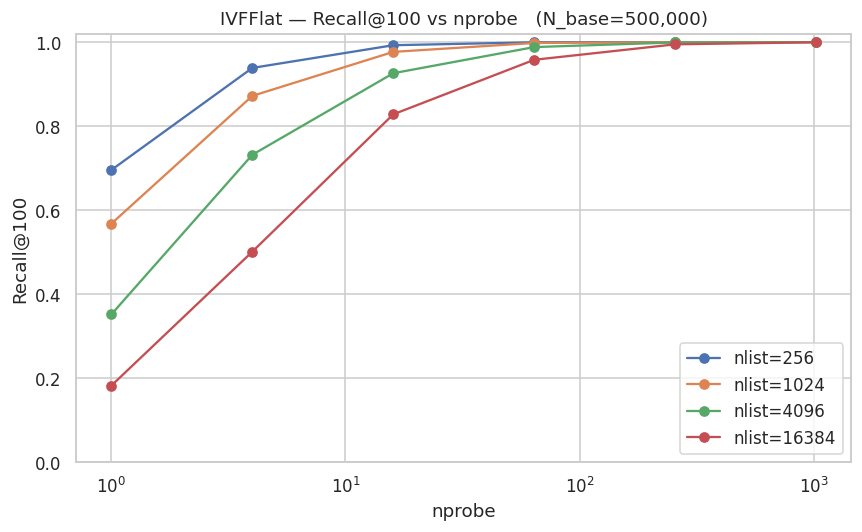

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
for nl, sub in df_ivf.groupby('nlist'):
    sub = sub.sort_values('nprobe')
    ax.plot(sub.nprobe, sub.recall_100, marker='o', label=f'nlist={nl}')
ax.set_xscale('log'); ax.set_xlabel('nprobe'); ax.set_ylabel('Recall@100')
ax.set_title(f'IVFFlat — Recall@100 vs nprobe   (N_base={N_SWEEP:,})')
ax.legend(); ax.set_ylim(0, 1.02)
plt.tight_layout(); plt.savefig(DOCS_IMG / '02_ivf_recall_vs_nprobe.png', dpi=120); plt.show()

### Plot 2 — Heatmap nlist × nprobe → Recall@100

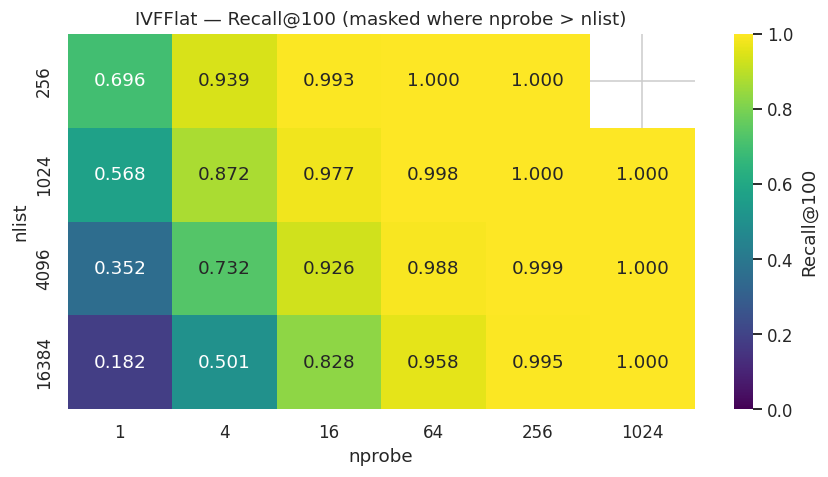

In [11]:
pivot = df_ivf.pivot(index='nlist', columns='nprobe', values='recall_100')
# Invalid IVF configs: nprobe must be ≤ nlist — mask so heatmap shows gaps explicitly
mask_invalid = np.zeros_like(pivot, dtype=bool)
for i, nl in enumerate(pivot.index):
    for j, np_ in enumerate(pivot.columns):
        if int(np_) > int(nl):
            mask_invalid[i, j] = True
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.heatmap(pivot, mask=mask_invalid, annot=True, fmt='.3f', cmap='viridis', vmin=0, vmax=1,
            ax=ax, cbar_kws={'label': 'Recall@100'})
ax.set_title('IVFFlat — Recall@100 (masked where nprobe > nlist)')
plt.tight_layout(); plt.savefig(DOCS_IMG / '02_ivf_heatmap.png', dpi=120); plt.show()

### Plot 3 — QPS vs Recall@100 Pareto frontier

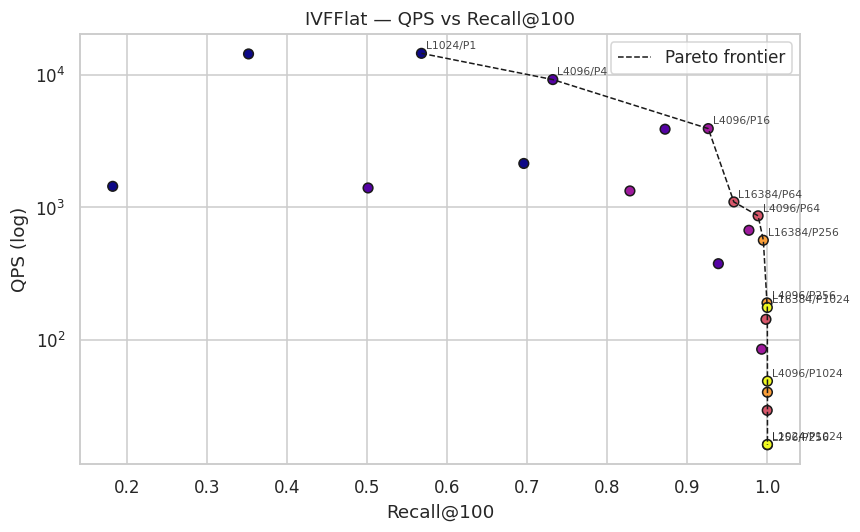

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_ivf.recall_100, df_ivf.qps, c=np.log2(df_ivf.nprobe.values+1),
           cmap='plasma', s=40, edgecolors='k')
mask = utils.pareto_frontier(df_ivf.recall_100.values, df_ivf.qps.values)
order = np.argsort(df_ivf.recall_100.values[mask])
ax.plot(df_ivf.recall_100.values[mask][order], df_ivf.qps.values[mask][order],
        'k--', lw=1, label='Pareto frontier')
# Annotate Pareto points only (avoids clutter)
dfm = df_ivf.iloc[np.where(mask)[0]].sort_values('recall_100')
for _, r in dfm.iterrows():
    ax.annotate(f"L{int(r.nlist)}/P{int(r.nprobe)}", (r.recall_100, r.qps),
                fontsize=7, alpha=0.85, xytext=(3, 3), textcoords='offset points')
ax.set_yscale('log'); ax.set_xlabel('Recall@100'); ax.set_ylabel('QPS (log)')
ax.set_title('IVFFlat — QPS vs Recall@100')
ax.legend()
plt.tight_layout(); plt.savefig(DOCS_IMG / '02_ivf_pareto.png', dpi=120); plt.show()

### Plot 4 — QPS vs nprobe (per nlist)

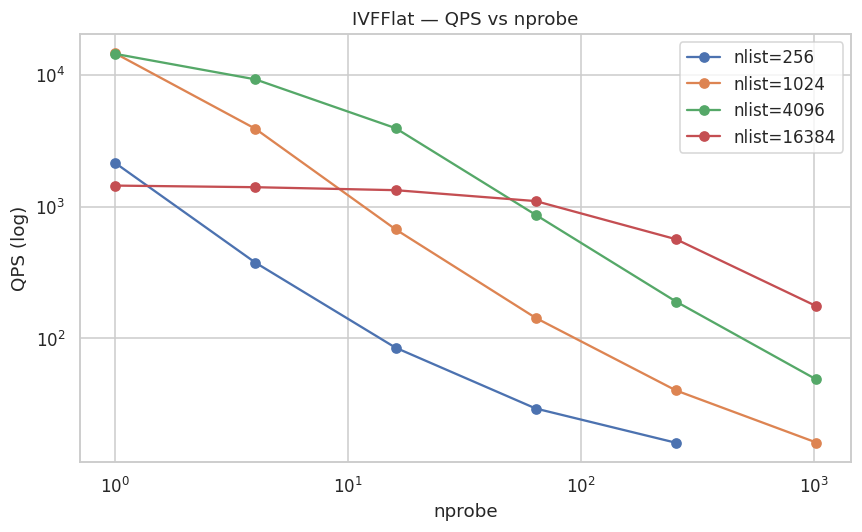

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
for nl, sub in df_ivf.groupby('nlist'):
    sub = sub.sort_values('nprobe')
    ax.plot(sub.nprobe, sub.qps, marker='o', label=f'nlist={nl}')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('nprobe'); ax.set_ylabel('QPS (log)')
ax.set_title('IVFFlat — QPS vs nprobe')
ax.legend(); plt.tight_layout()
plt.savefig(DOCS_IMG / '02_ivf_qps_vs_nprobe.png', dpi=120); plt.show()

### Plot 5 — Build time vs nlist

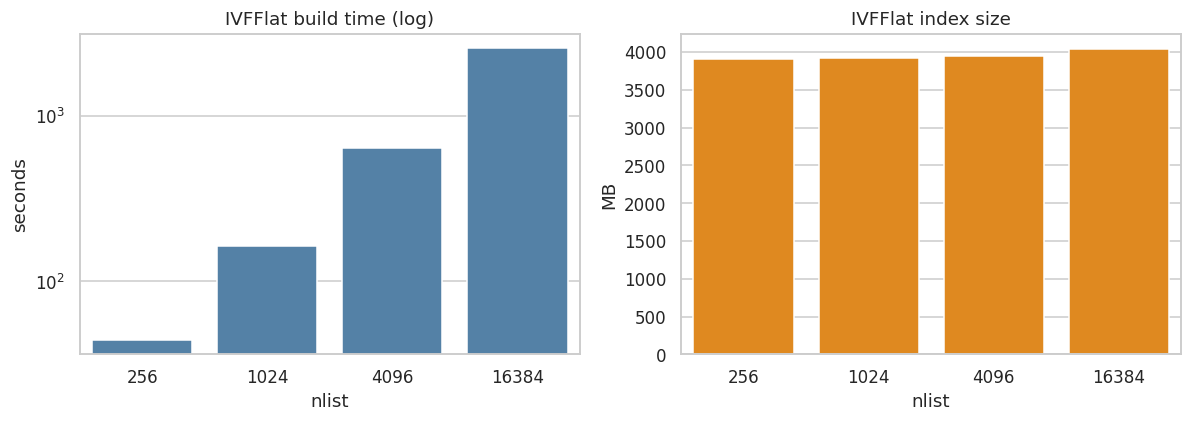

,nlist,build_s,size_mb
0,256,44.261979,3912.066783
1,1024,162.560839,3918.072642
2,4096,640.391776,3942.096080
3,16384,2567.302965,4038.189830


In [14]:
df_bt = df_ivf.drop_duplicates('nlist')[['nlist', 'build_s', 'size_mb']]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=df_bt, x='nlist', y='build_s', ax=ax[0], color='steelblue')
ax[0].set_yscale('log')
ax[0].set_title('IVFFlat build time (log)'); ax[0].set_ylabel('seconds')
sns.barplot(data=df_bt, x='nlist', y='size_mb', ax=ax[1], color='darkorange')
ax[1].set_title('IVFFlat index size'); ax[1].set_ylabel('MB')
plt.tight_layout(); plt.savefig(DOCS_IMG / '02_ivf_build_size.png', dpi=120); plt.show()
display(df_bt.reset_index(drop=True))

## IVF+PQ sweep — nlist × PQ M

Full grid over `PQ_NLIST_GRID × PQ_M_GRID` (not a single best nlist from IVFFlat).

In [15]:
IVF_PQ_PATH = RESULTS / 'ivf_pq.csv'
utils.init_results_csv(IVF_PQ_PATH)
print('IVFPQ checkpoint:', IVF_PQ_PATH)

# SQ sweep is now multi-nlist (SQ_NLIST_GRID); keep best_nlist as the *reference*
# IVFFlat point used in cross-family Pareto overlays only.
best_nlist = int((df_ivf
              .groupby('nlist')['recall_100'].max()
              .idxmax()))
print(f'reference IVFFlat nlist for plots: {best_nlist}  ·  SQ_NLIST_GRID={SQ_NLIST_GRID}')

IVFPQ checkpoint: results/full/ivf_pq.csv
reference IVFFlat nlist for plots: 256  ·  SQ_NLIST_GRID=[256, 1024, 4096]


#### IVF+PQ — nlist=1024 M=32

In [16]:
if 1024 not in PQ_NLIST_GRID or 32 not in PQ_M_GRID:
    print('skip IVFPQ nlist=1024 M=32')
else:
    rows = []
    quant = faiss.IndexFlatL2(DIM)
    idx = faiss.IndexIVFPQ(quant, DIM, 1024, int(32), int(PQ_NBITS))
    idx.cp.min_points_per_centroid = 5
    idx.cp.max_points_per_centroid = max(256, len(train_x) // 1024)
    with utils.timed('train+add PQ nlist=1024 M=32', sample_rss_peak=True) as tb:
        idx.train(train_x)
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_mb = tb.rss_after_mb
    rss_peak_mb = tb.rss_peak_mb
    rss_delta_mb = tb.rss_delta_mb
    print(f'[PQ nlist={1024:5} M={32:4}]  build {tb.elapsed:6.1f}s · size {size_mb:7.1f} MB')
    for nprobe in NPROBE_GRID:
        if nprobe > 1024:
            continue
        idx.nprobe = nprobe
        qps, lat_ms, lat_p99_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='IVFPQ', nlist=1024, nprobe=nprobe, M=32, nbits=PQ_NBITS,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        rss_delta_mb=rss_delta_mb, **utils.bench_meta(),
                        qps=qps, latency_ms=lat_ms, latency_p99_ms=lat_p99_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP))
        print(f'    nprobe={nprobe:5}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx, quant; gc.collect()
    utils.append_results(rows, IVF_PQ_PATH)

add (n=500,000, batch=50,000):   0%|                                                                                                 | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|████████▉                                                                                | 1/10 [00:02<00:19,  2.22s/it]

add (n=500,000, batch=50,000):  20%|█████████████████▊                                                                       | 2/10 [00:04<00:17,  2.19s/it]

add (n=500,000, batch=50,000):  30%|██████████████████████████▋                                                              | 3/10 [00:06<00:15,  2.18s/it]

add (n=500,000, batch=50,000):  40%|███████████████████████████████████▌                                                     | 4/10 [00:08<00:13,  2.19s/it]

...

    nprobe=    4  qps= 35614.8  R@100=0.598


    nprobe=   16  qps= 21327.7  R@100=0.607


    nprobe=   64  qps=  8191.3  R@100=0.607


    nprobe=  256  qps=  2820.5  R@100=0.607


    nprobe= 1024  qps=  1027.9  R@100=0.607


#### IVF+PQ — nlist=1024 M=64

In [17]:
if 1024 not in PQ_NLIST_GRID or 64 not in PQ_M_GRID:
    print('skip IVFPQ nlist=1024 M=64')
else:
    rows = []
    quant = faiss.IndexFlatL2(DIM)
    idx = faiss.IndexIVFPQ(quant, DIM, 1024, int(64), int(PQ_NBITS))
    idx.cp.min_points_per_centroid = 5
    idx.cp.max_points_per_centroid = max(256, len(train_x) // 1024)
    with utils.timed('train+add PQ nlist=1024 M=64', sample_rss_peak=True) as tb:
        idx.train(train_x)
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_mb = tb.rss_after_mb
    rss_peak_mb = tb.rss_peak_mb
    rss_delta_mb = tb.rss_delta_mb
    print(f'[PQ nlist={1024:5} M={64:4}]  build {tb.elapsed:6.1f}s · size {size_mb:7.1f} MB')
    for nprobe in NPROBE_GRID:
        if nprobe > 1024:
            continue
        idx.nprobe = nprobe
        qps, lat_ms, lat_p99_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='IVFPQ', nlist=1024, nprobe=nprobe, M=64, nbits=PQ_NBITS,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        rss_delta_mb=rss_delta_mb, **utils.bench_meta(),
                        qps=qps, latency_ms=lat_ms, latency_p99_ms=lat_p99_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP))
        print(f'    nprobe={nprobe:5}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx, quant; gc.collect()
    utils.append_results(rows, IVF_PQ_PATH)

add (n=500,000, batch=50,000):   0%|                                                                                                 | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|████████▉                                                                                | 1/10 [00:02<00:21,  2.44s/it]

add (n=500,000, batch=50,000):  20%|█████████████████▊                                                                       | 2/10 [00:04<00:19,  2.44s/it]

add (n=500,000, batch=50,000):  30%|██████████████████████████▋                                                              | 3/10 [00:07<00:17,  2.45s/it]

add (n=500,000, batch=50,000):  40%|███████████████████████████████████▌                                                     | 4/10 [00:09<00:14,  2.44s/it]

...

    nprobe=    4  qps= 29719.8  R@100=0.674


    nprobe=   16  qps= 14449.1  R@100=0.690


    nprobe=   64  qps=  4794.8  R@100=0.691


    nprobe=  256  qps=  1431.9  R@100=0.691


    nprobe= 1024  qps=   573.0  R@100=0.691


#### IVF+PQ — nlist=1024 M=128

In [18]:
if 1024 not in PQ_NLIST_GRID or 128 not in PQ_M_GRID:
    print('skip IVFPQ nlist=1024 M=128')
else:
    rows = []
    quant = faiss.IndexFlatL2(DIM)
    idx = faiss.IndexIVFPQ(quant, DIM, 1024, int(128), int(PQ_NBITS))
    idx.cp.min_points_per_centroid = 5
    idx.cp.max_points_per_centroid = max(256, len(train_x) // 1024)
    with utils.timed('train+add PQ nlist=1024 M=128', sample_rss_peak=True) as tb:
        idx.train(train_x)
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_mb = tb.rss_after_mb
    rss_peak_mb = tb.rss_peak_mb
    rss_delta_mb = tb.rss_delta_mb
    print(f'[PQ nlist={1024:5} M={128:4}]  build {tb.elapsed:6.1f}s · size {size_mb:7.1f} MB')
    for nprobe in NPROBE_GRID:
        if nprobe > 1024:
            continue
        idx.nprobe = nprobe
        qps, lat_ms, lat_p99_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='IVFPQ', nlist=1024, nprobe=nprobe, M=128, nbits=PQ_NBITS,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        rss_delta_mb=rss_delta_mb, **utils.bench_meta(),
                        qps=qps, latency_ms=lat_ms, latency_p99_ms=lat_p99_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP))
        print(f'    nprobe={nprobe:5}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx, quant; gc.collect()
    utils.append_results(rows, IVF_PQ_PATH)

add (n=500,000, batch=50,000):   0%|                                                                                                 | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|████████▉                                                                                | 1/10 [00:03<00:31,  3.48s/it]

add (n=500,000, batch=50,000):  20%|█████████████████▊                                                                       | 2/10 [00:06<00:27,  3.49s/it]

add (n=500,000, batch=50,000):  30%|██████████████████████████▋                                                              | 3/10 [00:10<00:24,  3.51s/it]

add (n=500,000, batch=50,000):  40%|███████████████████████████████████▌                                                     | 4/10 [00:14<00:21,  3.51s/it]

...

    nprobe=    4  qps= 18898.1  R@100=0.752


    nprobe=   16  qps=  7417.6  R@100=0.786


    nprobe=   64  qps=  1922.1  R@100=0.788


    nprobe=  256  qps=   668.3  R@100=0.788


    nprobe= 1024  qps=   255.5  R@100=0.788


#### IVF+PQ — nlist=4096 M=32

In [19]:
if 4096 not in PQ_NLIST_GRID or 32 not in PQ_M_GRID:
    print('skip IVFPQ nlist=4096 M=32')
else:
    rows = []
    quant = faiss.IndexFlatL2(DIM)
    idx = faiss.IndexIVFPQ(quant, DIM, 4096, int(32), int(PQ_NBITS))
    idx.cp.min_points_per_centroid = 5
    idx.cp.max_points_per_centroid = max(256, len(train_x) // 4096)
    with utils.timed('train+add PQ nlist=4096 M=32', sample_rss_peak=True) as tb:
        idx.train(train_x)
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_mb = tb.rss_after_mb
    rss_peak_mb = tb.rss_peak_mb
    rss_delta_mb = tb.rss_delta_mb
    print(f'[PQ nlist={4096:5} M={32:4}]  build {tb.elapsed:6.1f}s · size {size_mb:7.1f} MB')
    for nprobe in NPROBE_GRID:
        if nprobe > 4096:
            continue
        idx.nprobe = nprobe
        qps, lat_ms, lat_p99_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='IVFPQ', nlist=4096, nprobe=nprobe, M=32, nbits=PQ_NBITS,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        rss_delta_mb=rss_delta_mb, **utils.bench_meta(),
                        qps=qps, latency_ms=lat_ms, latency_p99_ms=lat_p99_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP))
        print(f'    nprobe={nprobe:5}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx, quant; gc.collect()
    utils.append_results(rows, IVF_PQ_PATH)

add (n=500,000, batch=50,000):   0%|                                                                                                 | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|████████▉                                                                                | 1/10 [00:06<00:59,  6.65s/it]

add (n=500,000, batch=50,000):  20%|█████████████████▊                                                                       | 2/10 [00:13<00:53,  6.67s/it]

add (n=500,000, batch=50,000):  30%|██████████████████████████▋                                                              | 3/10 [00:19<00:46,  6.63s/it]

add (n=500,000, batch=50,000):  40%|███████████████████████████████████▌                                                     | 4/10 [00:26<00:39,  6.61s/it]

...

    nprobe=    4  qps= 14759.4  R@100=0.561


    nprobe=   16  qps= 13605.9  R@100=0.588


    nprobe=   64  qps= 10521.9  R@100=0.589


    nprobe=  256  qps=  5581.3  R@100=0.590


    nprobe= 1024  qps=  2117.6  R@100=0.590


#### IVF+PQ — nlist=4096 M=64

In [20]:
if 4096 not in PQ_NLIST_GRID or 64 not in PQ_M_GRID:
    print('skip IVFPQ nlist=4096 M=64')
else:
    rows = []
    quant = faiss.IndexFlatL2(DIM)
    idx = faiss.IndexIVFPQ(quant, DIM, 4096, int(64), int(PQ_NBITS))
    idx.cp.min_points_per_centroid = 5
    idx.cp.max_points_per_centroid = max(256, len(train_x) // 4096)
    with utils.timed('train+add PQ nlist=4096 M=64', sample_rss_peak=True) as tb:
        idx.train(train_x)
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_mb = tb.rss_after_mb
    rss_peak_mb = tb.rss_peak_mb
    rss_delta_mb = tb.rss_delta_mb
    print(f'[PQ nlist={4096:5} M={64:4}]  build {tb.elapsed:6.1f}s · size {size_mb:7.1f} MB')
    for nprobe in NPROBE_GRID:
        if nprobe > 4096:
            continue
        idx.nprobe = nprobe
        qps, lat_ms, lat_p99_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='IVFPQ', nlist=4096, nprobe=nprobe, M=64, nbits=PQ_NBITS,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        rss_delta_mb=rss_delta_mb, **utils.bench_meta(),
                        qps=qps, latency_ms=lat_ms, latency_p99_ms=lat_p99_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP))
        print(f'    nprobe={nprobe:5}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx, quant; gc.collect()
    utils.append_results(rows, IVF_PQ_PATH)

add (n=500,000, batch=50,000):   0%|                                                                                                 | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|████████▉                                                                                | 1/10 [00:06<01:02,  6.90s/it]

add (n=500,000, batch=50,000):  20%|█████████████████▊                                                                       | 2/10 [00:13<00:55,  6.90s/it]

add (n=500,000, batch=50,000):  30%|██████████████████████████▋                                                              | 3/10 [00:20<00:48,  6.90s/it]

add (n=500,000, batch=50,000):  40%|███████████████████████████████████▌                                                     | 4/10 [00:27<00:41,  6.90s/it]

...

    nprobe=    4  qps= 15188.6  R@100=0.621


    nprobe=   16  qps= 13177.8  R@100=0.673


    nprobe=   64  qps=  8432.7  R@100=0.677


    nprobe=  256  qps=  3601.6  R@100=0.677


    nprobe= 1024  qps=  1091.0  R@100=0.677


#### IVF+PQ — nlist=4096 M=128

In [21]:
if 4096 not in PQ_NLIST_GRID or 128 not in PQ_M_GRID:
    print('skip IVFPQ nlist=4096 M=128')
else:
    rows = []
    quant = faiss.IndexFlatL2(DIM)
    idx = faiss.IndexIVFPQ(quant, DIM, 4096, int(128), int(PQ_NBITS))
    idx.cp.min_points_per_centroid = 5
    idx.cp.max_points_per_centroid = max(256, len(train_x) // 4096)
    with utils.timed('train+add PQ nlist=4096 M=128', sample_rss_peak=True) as tb:
        idx.train(train_x)
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_mb = tb.rss_after_mb
    rss_peak_mb = tb.rss_peak_mb
    rss_delta_mb = tb.rss_delta_mb
    print(f'[PQ nlist={4096:5} M={128:4}]  build {tb.elapsed:6.1f}s · size {size_mb:7.1f} MB')
    for nprobe in NPROBE_GRID:
        if nprobe > 4096:
            continue
        idx.nprobe = nprobe
        qps, lat_ms, lat_p99_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='IVFPQ', nlist=4096, nprobe=nprobe, M=128, nbits=PQ_NBITS,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        rss_delta_mb=rss_delta_mb, **utils.bench_meta(),
                        qps=qps, latency_ms=lat_ms, latency_p99_ms=lat_p99_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP))
        print(f'    nprobe={nprobe:5}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx, quant; gc.collect()
    utils.append_results(rows, IVF_PQ_PATH)

add (n=500,000, batch=50,000):   0%|                                                                                                 | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|████████▉                                                                                | 1/10 [00:07<01:11,  7.93s/it]

add (n=500,000, batch=50,000):  20%|█████████████████▊                                                                       | 2/10 [00:15<01:03,  7.96s/it]

add (n=500,000, batch=50,000):  30%|██████████████████████████▋                                                              | 3/10 [00:23<00:55,  7.95s/it]

add (n=500,000, batch=50,000):  40%|███████████████████████████████████▌                                                     | 4/10 [00:31<00:47,  7.97s/it]

...

    nprobe=    4  qps= 13032.5  R@100=0.675


    nprobe=   16  qps= 10198.3  R@100=0.771


    nprobe=   64  qps=  5136.6  R@100=0.784


    nprobe=  256  qps=  1721.1  R@100=0.784


    nprobe= 1024  qps=   498.5  R@100=0.784


In [22]:
df_pq = pd.read_csv(IVF_PQ_PATH)
display(df_pq.tail(6))

,algo,nlist,nprobe,M,nbits,build_s,size_mb,rss_mb,rss_peak_mb,rss_delta_mb,faiss_threads,qps,latency_ms,latency_p99_ms,recall_1,recall_10,recall_100,n_base
30,IVFPQ,4096,1,128,8,673.874622,98.881275,7704.617188,15964.8125,568.398438,8,14803.696756,0.067592,0.072378,0.4460,0.46733,0.351251,500000
31,IVFPQ,4096,4,128,8,673.874622,98.881275,7704.617188,15964.8125,568.398438,8,13032.475305,0.075865,0.143721,0.6003,0.68428,0.675389,500000
32,IVFPQ,4096,16,128,8,673.874622,98.881275,7704.617188,15964.8125,568.398438,8,10198.322879,0.098367,0.158980,0.6275,0.72682,0.771396,500000
33,IVFPQ,4096,64,128,8,673.874622,98.881275,7704.617188,15964.8125,568.398438,8,5136.618667,0.194641,0.280263,0.6299,0.73077,0.783790,500000
34,IVFPQ,4096,256,128,8,673.874622,98.881275,7704.617188,15964.8125,568.398438,8,1721.078454,0.585061,0.772801,0.6301,0.73097,0.784394,500000
35,IVFPQ,4096,1024,128,8,673.874622,98.881275,7704.617188,15964.8125,568.398438,8,498.516588,2.006365,2.153039,0.6301,0.73097,0.784403,500000


### Plot 6 — IVF+PQ Recall@100 vs nprobe (per M)

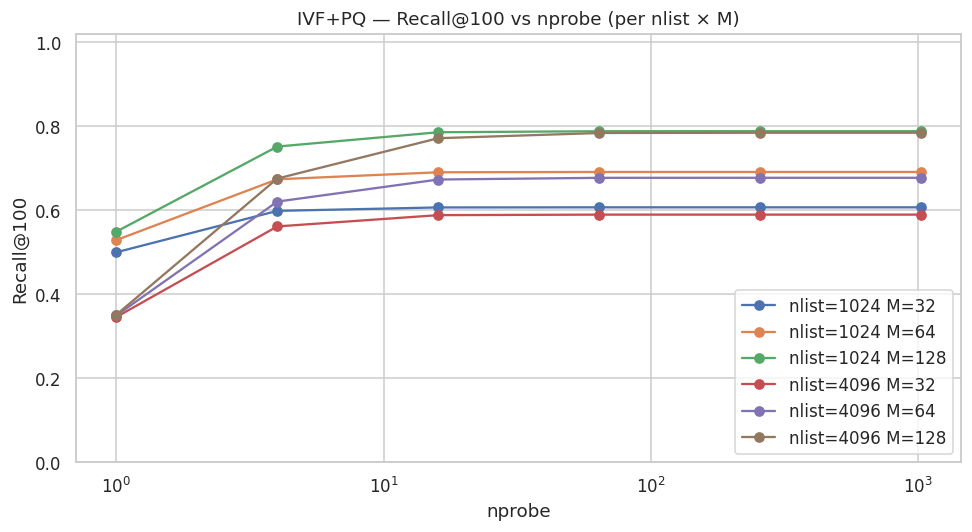

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))
for (nl, M), sub in df_pq.groupby(['nlist', 'M']):
    sub = sub.sort_values('nprobe')
    ax.plot(sub.nprobe, sub.recall_100, marker='o', label=f'nlist={int(nl)} M={int(M)}')
ax.set_xscale('log'); ax.set_xlabel('nprobe'); ax.set_ylabel('Recall@100')
ax.set_title('IVF+PQ — Recall@100 vs nprobe (per nlist × M)')
ax.legend(); ax.set_ylim(0, 1.02)
plt.tight_layout(); plt.savefig(DOCS_IMG / '02_ivfpq_recall.png', dpi=120); plt.show()

### Plot 7 — IVF+PQ Pareto QPS vs Recall@100 (per M)

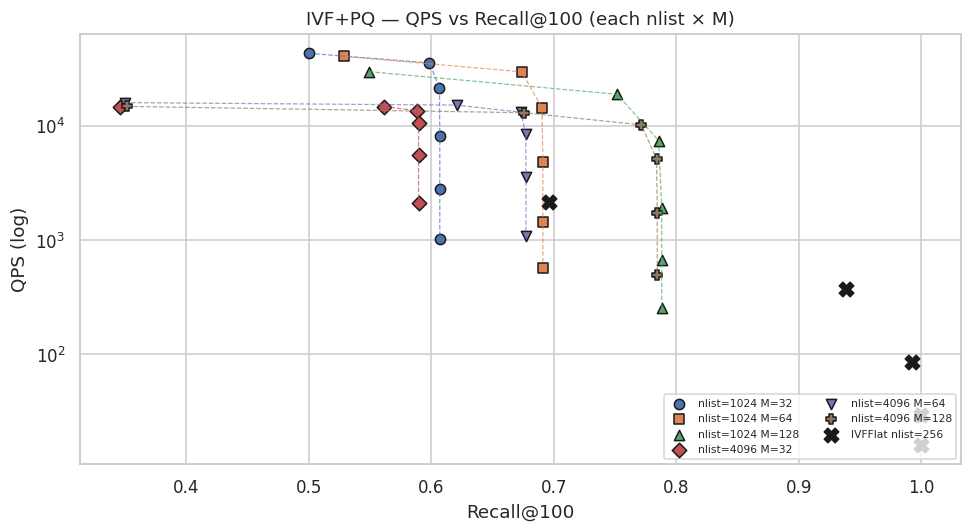

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))
markers = ['o', 's', '^', 'D', 'v', 'P']
for i, (nl, M) in enumerate(sorted({(int(r.nlist), int(r.M)) for _, r in df_pq.iterrows()})):
    sub = df_pq[(df_pq.nlist == nl) & (df_pq.M == M)]
    mk = markers[i % len(markers)]
    ax.scatter(sub.recall_100, sub.qps, marker=mk, s=45, edgecolors='k',
               label=f'nlist={nl} M={M}')
    ms = utils.pareto_frontier(sub.recall_100.values, sub.qps.values)
    if ms.any():
        o = np.argsort(sub.recall_100.values[ms])
        ax.plot(sub.recall_100.values[ms][o], sub.qps.values[ms][o], ls='--', lw=0.8, alpha=0.7)
ax.scatter(df_ivf[df_ivf.nlist==best_nlist].recall_100, df_ivf[df_ivf.nlist==best_nlist].qps,
           marker='X', color='k', s=90, label=f'IVFFlat nlist={best_nlist}', zorder=5)
ax.set_yscale('log'); ax.set_xlabel('Recall@100'); ax.set_ylabel('QPS (log)')
ax.set_title('IVF+PQ — QPS vs Recall@100 (each nlist × M)')
ax.legend(fontsize=7, ncol=2, loc='lower right')
plt.tight_layout(); plt.savefig(DOCS_IMG / '02_ivfpq_pareto.png', dpi=120); plt.show()

### Plot 8 — Index size vs PQ M (compression vs flat)

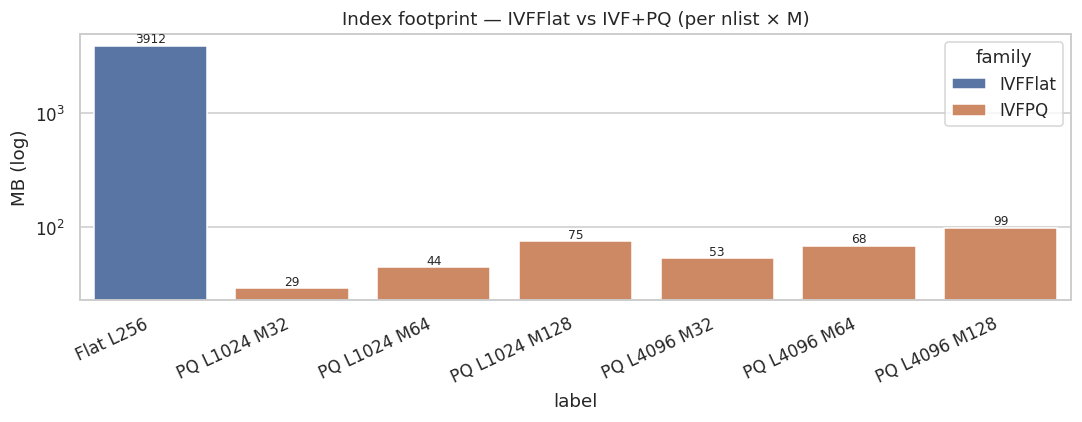

,family,nlist,M,size_mb,label
0,IVFFlat,256,NaN,3912.066783,Flat L256
1,IVFPQ,1024,32.0,29.081470,PQ L1024 M32
2,IVFPQ,1024,64.0,44.340260,PQ L1024 M64
3,IVFPQ,1024,128.0,74.857838,PQ L1024 M128
4,IVFPQ,4096,32.0,53.104908,PQ L4096 M32
5,IVFPQ,4096,64.0,68.363697,PQ L4096 M64
6,IVFPQ,4096,128.0,98.881275,PQ L4096 M128


In [25]:
size_rows = [{'family': 'IVFFlat', 'nlist': best_nlist, 'M': None,
              'size_mb': float(df_ivf[df_ivf.nlist==best_nlist].size_mb.iloc[0])}]
for nl in sorted(df_pq.nlist.unique()):
    for M in sorted(df_pq.M.unique()):
        sub = df_pq[(df_pq.nlist == nl) & (df_pq.M == M)]
        size_rows.append({'family': 'IVFPQ', 'nlist': int(nl), 'M': int(M),
                         'size_mb': float(sub.size_mb.iloc[0])})
size_df = pd.DataFrame(size_rows)
size_df['label'] = size_df.apply(
    lambda r: f"Flat L{int(r.nlist)}" if r.family == 'IVFFlat' else f"PQ L{int(r.nlist)} M{int(r.M)}",
    axis=1)
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=size_df, x='label', y='size_mb', hue='family', ax=ax, dodge=False)
ax.set_yscale('log'); ax.set_ylabel('MB (log)')
ax.set_title('Index footprint — IVFFlat vs IVF+PQ (per nlist × M)')
for i, (_, r) in enumerate(size_df.iterrows()):
    ax.text(i, r.size_mb, f'{r.size_mb:.0f}', ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=25, ha='right')
plt.tight_layout(); plt.savefig(DOCS_IMG / '02_ivfpq_size.png', dpi=120); plt.show()
display(size_df)

## IVF+ScalarQuantizer

One SQ variant per notebook cell (checkpointed CSV).

In [26]:
IVF_SQ_PATH = RESULTS / 'ivf_sq.csv'
utils.init_results_csv(IVF_SQ_PATH)
print('IVFSQ checkpoint:', IVF_SQ_PATH)

IVFSQ checkpoint: results/full/ivf_sq.csv


#### IVF+SQ — nlist=256 · SQ8

In [27]:
if 'SQ8' not in [t[0] for t in SQ_TYPES] or 256 not in SQ_NLIST_GRID:
    print('skip IVFSQ SQ8 nlist=256')
else:
    rows = []
    quant = faiss.IndexFlatL2(DIM)
    idx = faiss.IndexIVFScalarQuantizer(quant, DIM, 256, faiss.ScalarQuantizer.QT_8bit, faiss.METRIC_L2)
    idx.cp.min_points_per_centroid = 5
    idx.cp.max_points_per_centroid = max(256, len(train_x) // 256)
    with utils.timed('train+add SQ SQ8 nlist=256', sample_rss_peak=True) as tb:
        idx.train(train_x)
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_mb = tb.rss_after_mb
    rss_peak_mb = tb.rss_peak_mb
    rss_delta_mb = tb.rss_delta_mb
    print(f'[SQ SQ8 nlist={256:5}]  build {tb.elapsed:6.1f}s · size {size_mb:7.1f} MB')
    for nprobe in NPROBE_GRID:
        if nprobe > 256:
            continue
        idx.nprobe = nprobe
        qps, lat_ms, lat_p99_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='IVFSQ', sq='SQ8', nlist=256, nprobe=nprobe,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        rss_delta_mb=rss_delta_mb, **utils.bench_meta(),
                        qps=qps, latency_ms=lat_ms, latency_p99_ms=lat_p99_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP))
        print(f'    nprobe={nprobe:5}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx, quant; gc.collect()
    utils.append_results(rows, IVF_SQ_PATH)

add (n=500,000, batch=50,000):   0%|                                                                                                 | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|████████▉                                                                                | 1/10 [00:00<00:04,  2.19it/s]

add (n=500,000, batch=50,000):  20%|█████████████████▊                                                                       | 2/10 [00:00<00:03,  2.16it/s]

add (n=500,000, batch=50,000):  30%|██████████████████████████▋                                                              | 3/10 [00:01<00:03,  2.17it/s]

add (n=500,000, batch=50,000):  40%|███████████████████████████████████▌                                                     | 4/10 [00:01<00:02,  2.16it/s]

...

    nprobe=    1  qps=  5309.0  R@100=0.695


    nprobe=    4  qps=  1366.6  R@100=0.936


    nprobe=   16  qps=   368.9  R@100=0.987


    nprobe=   64  qps=   132.0  R@100=0.993


    nprobe=  256  qps=    73.3  R@100=0.993


#### IVF+SQ — nlist=256 · SQ4

In [28]:
if 'SQ4' not in [t[0] for t in SQ_TYPES] or 256 not in SQ_NLIST_GRID:
    print('skip IVFSQ SQ4 nlist=256')
else:
    rows = []
    quant = faiss.IndexFlatL2(DIM)
    idx = faiss.IndexIVFScalarQuantizer(quant, DIM, 256, faiss.ScalarQuantizer.QT_4bit, faiss.METRIC_L2)
    idx.cp.min_points_per_centroid = 5
    idx.cp.max_points_per_centroid = max(256, len(train_x) // 256)
    with utils.timed('train+add SQ SQ4 nlist=256', sample_rss_peak=True) as tb:
        idx.train(train_x)
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_mb = tb.rss_after_mb
    rss_peak_mb = tb.rss_peak_mb
    rss_delta_mb = tb.rss_delta_mb
    print(f'[SQ SQ4 nlist={256:5}]  build {tb.elapsed:6.1f}s · size {size_mb:7.1f} MB')
    for nprobe in NPROBE_GRID:
        if nprobe > 256:
            continue
        idx.nprobe = nprobe
        qps, lat_ms, lat_p99_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='IVFSQ', sq='SQ4', nlist=256, nprobe=nprobe,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        rss_delta_mb=rss_delta_mb, **utils.bench_meta(),
                        qps=qps, latency_ms=lat_ms, latency_p99_ms=lat_p99_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP))
        print(f'    nprobe={nprobe:5}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx, quant; gc.collect()
    utils.append_results(rows, IVF_SQ_PATH)

add (n=500,000, batch=50,000):   0%|                                                                                                 | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|████████▉                                                                                | 1/10 [00:00<00:04,  2.17it/s]

add (n=500,000, batch=50,000):  20%|█████████████████▊                                                                       | 2/10 [00:00<00:03,  2.12it/s]

add (n=500,000, batch=50,000):  30%|██████████████████████████▋                                                              | 3/10 [00:01<00:03,  2.14it/s]

add (n=500,000, batch=50,000):  40%|███████████████████████████████████▌                                                     | 4/10 [00:01<00:02,  2.15it/s]

...

    nprobe=    1  qps=  4144.0  R@100=0.668


    nprobe=    4  qps=  1113.4  R@100=0.865


    nprobe=   16  qps=   333.8  R@100=0.897


    nprobe=   64  qps=   126.8  R@100=0.900


    nprobe=  256  qps=    67.9  R@100=0.901


#### IVF+SQ — nlist=1024 · SQ8

In [29]:
if 'SQ8' not in [t[0] for t in SQ_TYPES] or 1024 not in SQ_NLIST_GRID:
    print('skip IVFSQ SQ8 nlist=1024')
else:
    rows = []
    quant = faiss.IndexFlatL2(DIM)
    idx = faiss.IndexIVFScalarQuantizer(quant, DIM, 1024, faiss.ScalarQuantizer.QT_8bit, faiss.METRIC_L2)
    idx.cp.min_points_per_centroid = 5
    idx.cp.max_points_per_centroid = max(256, len(train_x) // 1024)
    with utils.timed('train+add SQ SQ8 nlist=1024', sample_rss_peak=True) as tb:
        idx.train(train_x)
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_mb = tb.rss_after_mb
    rss_peak_mb = tb.rss_peak_mb
    rss_delta_mb = tb.rss_delta_mb
    print(f'[SQ SQ8 nlist={1024:5}]  build {tb.elapsed:6.1f}s · size {size_mb:7.1f} MB')
    for nprobe in NPROBE_GRID:
        if nprobe > 1024:
            continue
        idx.nprobe = nprobe
        qps, lat_ms, lat_p99_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='IVFSQ', sq='SQ8', nlist=1024, nprobe=nprobe,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        rss_delta_mb=rss_delta_mb, **utils.bench_meta(),
                        qps=qps, latency_ms=lat_ms, latency_p99_ms=lat_p99_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP))
        print(f'    nprobe={nprobe:5}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx, quant; gc.collect()
    utils.append_results(rows, IVF_SQ_PATH)

add (n=500,000, batch=50,000):   0%|                                                                                                 | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|████████▉                                                                                | 1/10 [00:01<00:13,  1.55s/it]

add (n=500,000, batch=50,000):  20%|█████████████████▊                                                                       | 2/10 [00:03<00:12,  1.55s/it]

add (n=500,000, batch=50,000):  30%|██████████████████████████▋                                                              | 3/10 [00:04<00:10,  1.55s/it]

add (n=500,000, batch=50,000):  40%|███████████████████████████████████▌                                                     | 4/10 [00:06<00:09,  1.56s/it]

...

    nprobe=    4  qps=  9733.6  R@100=0.871


    nprobe=   16  qps=  2444.5  R@100=0.974


    nprobe=   64  qps=   652.6  R@100=0.993


    nprobe=  256  qps=   178.6  R@100=0.994


    nprobe= 1024  qps=    67.6  R@100=0.994


#### IVF+SQ — nlist=1024 · SQ4

In [30]:
if 'SQ4' not in [t[0] for t in SQ_TYPES] or 1024 not in SQ_NLIST_GRID:
    print('skip IVFSQ SQ4 nlist=1024')
else:
    rows = []
    quant = faiss.IndexFlatL2(DIM)
    idx = faiss.IndexIVFScalarQuantizer(quant, DIM, 1024, faiss.ScalarQuantizer.QT_4bit, faiss.METRIC_L2)
    idx.cp.min_points_per_centroid = 5
    idx.cp.max_points_per_centroid = max(256, len(train_x) // 1024)
    with utils.timed('train+add SQ SQ4 nlist=1024', sample_rss_peak=True) as tb:
        idx.train(train_x)
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_mb = tb.rss_after_mb
    rss_peak_mb = tb.rss_peak_mb
    rss_delta_mb = tb.rss_delta_mb
    print(f'[SQ SQ4 nlist={1024:5}]  build {tb.elapsed:6.1f}s · size {size_mb:7.1f} MB')
    for nprobe in NPROBE_GRID:
        if nprobe > 1024:
            continue
        idx.nprobe = nprobe
        qps, lat_ms, lat_p99_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='IVFSQ', sq='SQ4', nlist=1024, nprobe=nprobe,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        rss_delta_mb=rss_delta_mb, **utils.bench_meta(),
                        qps=qps, latency_ms=lat_ms, latency_p99_ms=lat_p99_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP))
        print(f'    nprobe={nprobe:5}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx, quant; gc.collect()
    utils.append_results(rows, IVF_SQ_PATH)

add (n=500,000, batch=50,000):   0%|                                                                                                 | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|████████▉                                                                                | 1/10 [00:01<00:14,  1.57s/it]

add (n=500,000, batch=50,000):  20%|█████████████████▊                                                                       | 2/10 [00:03<00:12,  1.57s/it]

add (n=500,000, batch=50,000):  30%|██████████████████████████▋                                                              | 3/10 [00:04<00:10,  1.56s/it]

add (n=500,000, batch=50,000):  40%|███████████████████████████████████▌                                                     | 4/10 [00:06<00:09,  1.57s/it]

...

    nprobe=    4  qps=  8397.7  R@100=0.833


    nprobe=   16  qps=  1970.4  R@100=0.904


    nprobe=   64  qps=   569.6  R@100=0.914


    nprobe=  256  qps=   177.6  R@100=0.915


    nprobe= 1024  qps=    70.3  R@100=0.915


#### IVF+SQ — nlist=4096 · SQ8

In [31]:
if 'SQ8' not in [t[0] for t in SQ_TYPES] or 4096 not in SQ_NLIST_GRID:
    print('skip IVFSQ SQ8 nlist=4096')
else:
    rows = []
    quant = faiss.IndexFlatL2(DIM)
    idx = faiss.IndexIVFScalarQuantizer(quant, DIM, 4096, faiss.ScalarQuantizer.QT_8bit, faiss.METRIC_L2)
    idx.cp.min_points_per_centroid = 5
    idx.cp.max_points_per_centroid = max(256, len(train_x) // 4096)
    with utils.timed('train+add SQ SQ8 nlist=4096', sample_rss_peak=True) as tb:
        idx.train(train_x)
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_mb = tb.rss_after_mb
    rss_peak_mb = tb.rss_peak_mb
    rss_delta_mb = tb.rss_delta_mb
    print(f'[SQ SQ8 nlist={4096:5}]  build {tb.elapsed:6.1f}s · size {size_mb:7.1f} MB')
    for nprobe in NPROBE_GRID:
        if nprobe > 4096:
            continue
        idx.nprobe = nprobe
        qps, lat_ms, lat_p99_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='IVFSQ', sq='SQ8', nlist=4096, nprobe=nprobe,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        rss_delta_mb=rss_delta_mb, **utils.bench_meta(),
                        qps=qps, latency_ms=lat_ms, latency_p99_ms=lat_p99_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP))
        print(f'    nprobe={nprobe:5}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx, quant; gc.collect()
    utils.append_results(rows, IVF_SQ_PATH)

add (n=500,000, batch=50,000):   0%|                                                                                                 | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|████████▉                                                                                | 1/10 [00:05<00:53,  6.00s/it]

add (n=500,000, batch=50,000):  20%|█████████████████▊                                                                       | 2/10 [00:11<00:47,  5.99s/it]

add (n=500,000, batch=50,000):  30%|██████████████████████████▋                                                              | 3/10 [00:17<00:41,  6.00s/it]

add (n=500,000, batch=50,000):  40%|███████████████████████████████████▌                                                     | 4/10 [00:23<00:36,  6.00s/it]

...

    nprobe=    4  qps= 12849.8  R@100=0.732


    nprobe=   16  qps=  7650.3  R@100=0.924


    nprobe=   64  qps=  2865.2  R@100=0.985


    nprobe=  256  qps=   810.1  R@100=0.994


    nprobe= 1024  qps=   212.6  R@100=0.995


#### IVF+SQ — nlist=4096 · SQ4

In [32]:
if 'SQ4' not in [t[0] for t in SQ_TYPES] or 4096 not in SQ_NLIST_GRID:
    print('skip IVFSQ SQ4 nlist=4096')
else:
    rows = []
    quant = faiss.IndexFlatL2(DIM)
    idx = faiss.IndexIVFScalarQuantizer(quant, DIM, 4096, faiss.ScalarQuantizer.QT_4bit, faiss.METRIC_L2)
    idx.cp.min_points_per_centroid = 5
    idx.cp.max_points_per_centroid = max(256, len(train_x) // 4096)
    with utils.timed('train+add SQ SQ4 nlist=4096', sample_rss_peak=True) as tb:
        idx.train(train_x)
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_mb = tb.rss_after_mb
    rss_peak_mb = tb.rss_peak_mb
    rss_delta_mb = tb.rss_delta_mb
    print(f'[SQ SQ4 nlist={4096:5}]  build {tb.elapsed:6.1f}s · size {size_mb:7.1f} MB')
    for nprobe in NPROBE_GRID:
        if nprobe > 4096:
            continue
        idx.nprobe = nprobe
        qps, lat_ms, lat_p99_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='IVFSQ', sq='SQ4', nlist=4096, nprobe=nprobe,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        rss_delta_mb=rss_delta_mb, **utils.bench_meta(),
                        qps=qps, latency_ms=lat_ms, latency_p99_ms=lat_p99_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP))
        print(f'    nprobe={nprobe:5}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx, quant; gc.collect()
    utils.append_results(rows, IVF_SQ_PATH)

add (n=500,000, batch=50,000):   0%|                                                                                                 | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|████████▉                                                                                | 1/10 [00:05<00:53,  5.99s/it]

add (n=500,000, batch=50,000):  20%|█████████████████▊                                                                       | 2/10 [00:11<00:47,  6.00s/it]

add (n=500,000, batch=50,000):  30%|██████████████████████████▋                                                              | 3/10 [00:17<00:41,  6.00s/it]

add (n=500,000, batch=50,000):  40%|███████████████████████████████████▌                                                     | 4/10 [00:23<00:35,  5.99s/it]

...

    nprobe=    4  qps= 12555.2  R@100=0.720


    nprobe=   16  qps=  7058.3  R@100=0.883


    nprobe=   64  qps=  2138.7  R@100=0.920


    nprobe=  256  qps=   607.6  R@100=0.925


    nprobe= 1024  qps=   182.6  R@100=0.925


In [33]:
df_sq = pd.read_csv(IVF_SQ_PATH)
display(df_sq)

,algo,sq,nlist,nprobe,build_s,size_mb,rss_mb,rss_peak_mb,rss_delta_mb,faiss_threads,qps,latency_ms,latency_p99_ms,recall_1,recall_10,recall_100,n_base
0,IVFSQ,SQ8,256,1,45.194477,982.394951,7422.539062,11302.578125,214.546875,8,5308.998185,0.188211,0.324335,0.7644,0.74739,0.694823,500000
1,IVFSQ,SQ8,256,4,45.194477,982.394951,7422.539062,11302.578125,214.546875,8,1366.551780,0.730213,1.113581,0.9548,0.95099,0.935638,500000
2,IVFSQ,SQ8,256,16,45.194477,982.394951,7422.539062,11302.578125,214.546875,8,368.872902,2.710394,3.159084,0.9826,0.98461,0.986948,500000
3,IVFSQ,SQ8,256,64,45.194477,982.394951,7422.539062,11302.578125,214.546875,8,132.028825,7.571904,8.122133,0.9847,0.98759,0.993006,500000
4,IVFSQ,SQ8,256,256,45.194477,982.394951,7422.539062,11302.578125,214.546875,8,73.277080,13.636650,14.703910,0.9847,0.98768,0.993241,500000
5,IVFSQ,SQ4,256,1,45.404562,494.113701,7278.585938,11176.769531,45.191406,8,4143.952695,0.241651,0.435886,0.6145,0.67494,0.668454,500000
6,IVFSQ,SQ4,256,4,45.404562,494.113701,7278.585938,11176.769531,45.191406,8,1113.368865,0.897458,1.323212,0.7438,0.82148,0.864660,500000
7,IVFSQ,SQ4,256,16,45.404562,494.113701,7278.585938,11176.769531,45.191406,8,333.846978,2.995118,3.509878,0.7629,0.84033,0.896779,500000
8,IVFSQ,SQ4,256,64,45.404562,494.113701,7278.585938,11176.769531,45.191406,8,126.772130,7.889625,8.121973,0.7645,0.84194,0.900441,500000
9,IVFSQ,SQ4,256,256,45.404562,494.113701,7278.585938,11176.769531,45.191406,8,67.946411,14.718883,14.788998,0.7645,0.84199,0.900586,500000


### Plot 9 — SQ vs PQ vs Flat at the same nlist (Pareto)

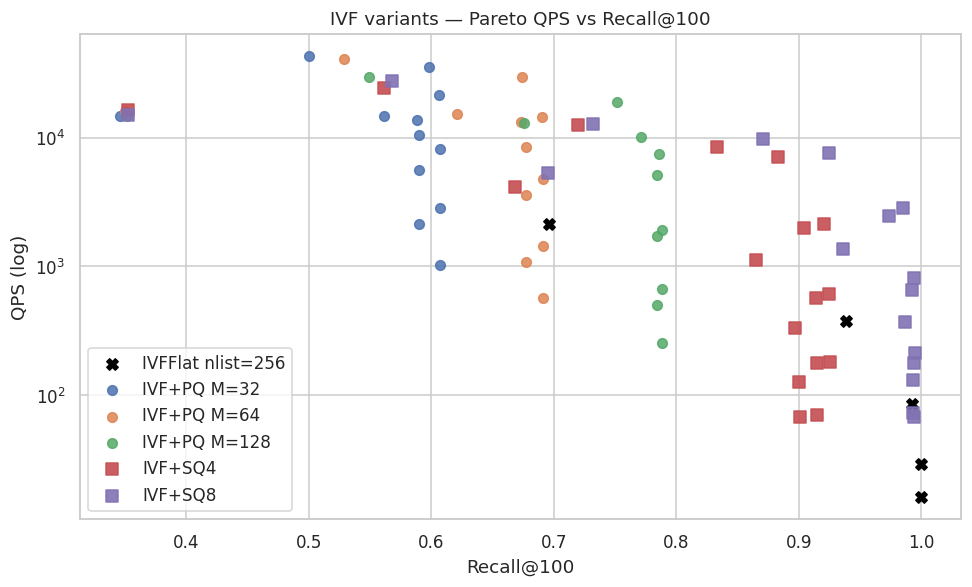

[mem after IVF sweeps]  RSS=2.77 GB  ·  free=27.40 GB  ·  used%=16
rows=93  → results/full/ivf_all.csv


In [34]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(df_ivf[df_ivf.nlist==best_nlist].recall_100, df_ivf[df_ivf.nlist==best_nlist].qps,
           label=f'IVFFlat nlist={best_nlist}', color='black', s=55, marker='X')
for M, sub in df_pq.groupby('M'):
    ax.scatter(sub.recall_100, sub.qps, label=f'IVF+PQ M={M}', s=40, alpha=0.85)
for name, sub in df_sq.groupby('sq'):
    ax.scatter(sub.recall_100, sub.qps, label=f'IVF+{name}', s=70, marker='s', alpha=0.9)
ax.set_yscale('log'); ax.set_xlabel('Recall@100'); ax.set_ylabel('QPS (log)')
ax.set_title('IVF variants — Pareto QPS vs Recall@100')
ax.legend()
plt.tight_layout(); plt.savefig(DOCS_IMG / '02_ivf_all_pareto.png', dpi=120); plt.show()

# Release training slice (~1.6 GB) before notebooks save and plots render.
try:
    del train_x
except NameError:
    pass
gc.collect()
utils.print_mem('after IVF sweeps')

# Persist combined for notebook 05
df_all = pd.concat([df_ivf, df_pq, df_sq], ignore_index=True)
df_all.to_csv(RESULTS / 'ivf_all.csv', index=False)
print(f'rows={len(df_all)}  → {RESULTS / "ivf_all.csv"}')

## Summary

Notable observations to keep in mind when reading `05_comparison.ipynb`:

* The IVFFlat upper bound on Recall@100 is set by `nprobe / nlist`. At the largest
  `nlist`/`nprobe` ratio we should saturate to ≥ 0.99.
* IVF+PQ trades index size for recall — index footprint drops by ~50–100× while
  recall stays within ~10–20 % of Flat **only at high nprobe**.
* IVF+ScalarQuantizer is a middle ground — 4× compression with minimal recall loss.